# Day 10 Tutorial：多随机种子稳定性

## Goal

固定数据划分和随机森林全部参数，仅改变 `random_state`，保存逐 seed 指标、汇总统计与同 seed 复现检查。


## Setup

数据由固定 seed 生成；训练/验证行只划分一次。为降低环境差异，随机森林使用 `n_jobs=1`。


In [1]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

DATA_SEED = 42
SPLIT_SEED = 17
SEEDS = [0, 1, 2, 3, 4, 42, 100, 2026]

print({"python": platform.python_version(), "sklearn": sklearn.__version__, "seeds": SEEDS})


{'python': '3.10.20', 'sklearn': '1.7.2', 'seeds': [0, 1, 2, 3, 4, 42, 100, 2026]}


## Steps

### 1. 固定同一份训练/验证数据


In [2]:
X, y = make_regression(
    n_samples=120, n_features=6, n_informative=5, noise=18.0, random_state=DATA_SEED
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, random_state=SPLIT_SEED
)
print({"train": X_train.shape, "validation": X_valid.shape})


{'train': (90, 6), 'validation': (30, 6)}


### 2. 封装一次运行

模型在函数内新建，保证每个 seed 都从未拟合状态开始。


In [3]:
def run_one_seed(seed):
    model = RandomForestRegressor(
        n_estimators=60,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=seed,
        n_jobs=1,
    )
    model.fit(X_train, y_train)
    prediction = model.predict(X_valid)
    record = {
        "seed": seed,
        "valid_mae": float(mean_absolute_error(y_valid, prediction)),
        "valid_rmse": float(root_mean_squared_error(y_valid, prediction)),
        "valid_r2": float(r2_score(y_valid, prediction)),
        "prediction_mean": float(prediction.mean()),
    }
    return record, prediction

records = []
for seed in SEEDS:
    record, _ = run_one_seed(seed)
    records.append(record)

seed_results = pd.DataFrame(records)
display(seed_results.round(4))


,seed,valid_mae,valid_rmse,valid_r2,prediction_mean
0,0,35.1122,45.1259,0.6199,-7.8524
1,1,34.8438,43.5507,0.6460,-10.2594
2,2,35.3998,44.6527,0.6279,-6.3382
3,3,36.0361,45.1949,0.6188,-8.5089
4,4,32.6383,42.7781,0.6585,-12.5603
5,42,35.8908,46.1290,0.6029,-7.6838
6,100,32.7999,43.2518,0.6509,-6.2097
7,2026,31.8257,40.9870,0.6865,-8.5976


### 3. 汇总所有运行

汇总不删除逐次表。`std` 是八个观察 seed 的样本标准差。


,valid_mae,valid_rmse,valid_r2
mean,34.3183,43.9588,0.6389
std,1.6406,1.6464,0.0268
min,31.8257,40.9870,0.6029
max,36.0361,46.1290,0.6865


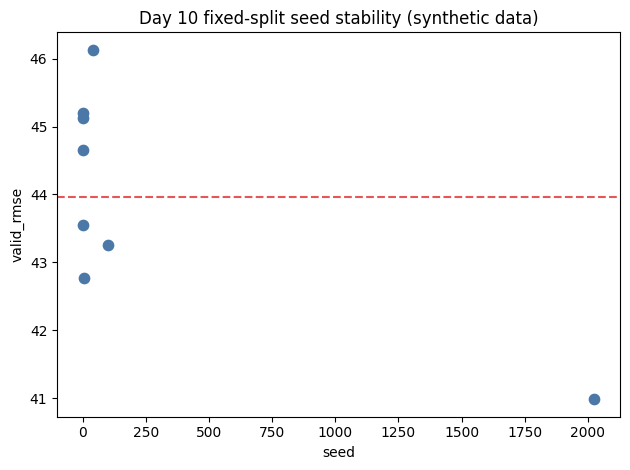

In [4]:
summary = seed_results[["valid_mae", "valid_rmse", "valid_r2"]].agg(
    ["mean", "std", "min", "max"]
)
display(summary.round(4))

ax = seed_results.plot.scatter(x="seed", y="valid_rmse", s=55, color="#4C78A8")
ax.axhline(summary.loc["mean", "valid_rmse"], color="#E45756", linestyle="--")
ax.set(title="Day 10 fixed-split seed stability (synthetic data)")
plt.tight_layout()
plt.show()


## Checks

同 seed 独立建模两次，预测应在当前固定环境中一致。


In [5]:
_, prediction_a = run_one_seed(42)
_, prediction_b = run_one_seed(42)
max_abs_difference = float(np.max(np.abs(prediction_a - prediction_b)))

assert seed_results["seed"].tolist() == SEEDS
assert len(seed_results) == len(SEEDS)
assert np.isfinite(seed_results.drop(columns="seed")).all().all()
assert np.allclose(prediction_a, prediction_b)
assert max_abs_difference == 0.0

print({"same_seed_max_abs_difference": max_abs_difference, "status": "checks passed"})


{'same_seed_max_abs_difference': 0.0, 'status': 'checks passed'}


## Next Steps

在自己的实验中先固定 seed 列表再运行，并记录数据、划分、特征、模型参数和版本。这里的标准差只描述固定划分下的模型随机性，不是划分波动、材料测量误差或领域迁移误差。
